In [15]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
from ast import literal_eval
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)

current = os.getcwd()
parent = os.path.dirname(current)
sys.path.append(parent)

vowels = [
    "AH", "OY", "AA", "AY", "ER", "AO", "UW", "IH", 
    "EH", "UH", "IY", "EY", "OW", "AE", "AW"
] 

converters = {
    "Word": str, 
    "Phonemes": literal_eval, 
    "No Stress": literal_eval, 
    "Prediction": literal_eval,
    "H1": literal_eval, 
    "C1": literal_eval
}

In [32]:
csv_path = "data/train_hidden.csv"
df = pd.read_csv(csv_path, index_col=0, converters=converters)

npy_path = "data/train_hidden.npy"
emb = np.load(npy_path)

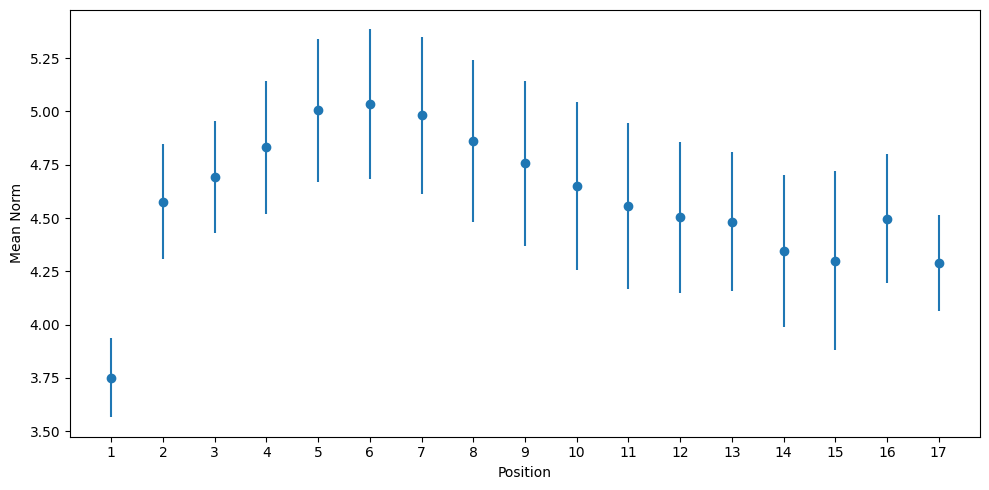

In [ ]:
def norm_by_position(df: pd.DataFrame, emb: np.ndarray) -> None:
    """Calculate average norm of the deltas of the embeddings by position."""

    max_length = df["Length"].max()
    positions = range(1, max_length+1)
    data = {pos: [] for pos in positions}

    # iterate through the dataframe
    for i, row in df.iterrows():
        length = row["Length"]
        prev = np.zeros(emb.shape[2])
        for pos in range(length):
            curr = emb[i, pos, :] # type: ignore
            delta = curr - prev
            data[pos+1].append(np.linalg.norm(delta))
            prev = curr

    # # print the size of the data
    # for pos, norms in data.items():
    #     print(f"Position {pos}: {len(norms)} deltas")

    # calculate the average deltas
    means = [np.mean(norms) for norms in data.values()]
    stds = [np.std(norms) for norms in data.values()]

    # plot the results
    plt.figure(figsize=(10, 5))
    plt.errorbar(positions, means, yerr=stds, fmt='o')
    plt.xlabel("Position")
    plt.ylabel("Mean Norm")
    plt.xticks(positions)
    plt.tight_layout()
    plt.show()

norm_by_position(df, emb)

/var/folders/lq/gkdcr_9s1qq4jxv0w46k1jg40000gn/T/ipykernel_1398/2154821816.py:22: RuntimeWarning: invalid value encountered in scalar divide
  sim = np.dot(p, d) / (np.linalg.norm(p) * np.linalg.norm(d))


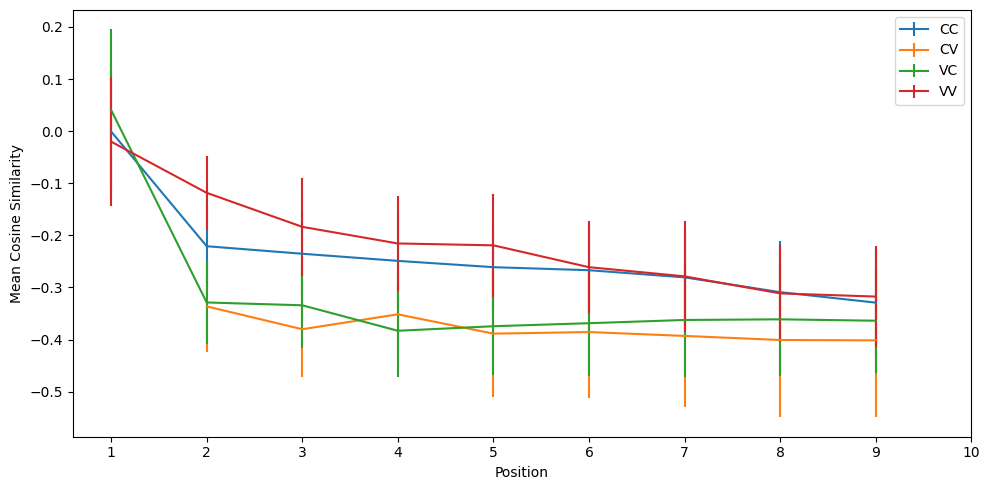

In [59]:
def cossim_by_position(df: pd.DataFrame, emb: np.ndarray) -> None:
    """Line plot with mean cosine similarity at each position for each bigram type."""
    df = df[df["Length"] > 1].copy()
    
    # max_len = df["Length"].max()
    max_len = 10
    types = ["CC", "CV", "VC", "VV"]
    posit = range(1, max_len + 1)
    data = {t: {j: [] for j in posit} for t in types}

    # iterate through the dataframe
    p = np.zeros(emb.shape[2])
    for i, row in df.iterrows():
        for j in range(1, min(row["Length"], max_len)):
            t1 = "V" if row["No Stress"][j-1] in vowels else "C"
            t2 = "V" if row["No Stress"][j] in vowels else "C"
            
            a = emb[i, j-1, :] # type: ignore
            b = emb[i, j, :] # type: ignore
            # sim = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
            d = a - b
            sim = np.dot(p, d) / (np.linalg.norm(p) * np.linalg.norm(d))
            p = d

            data[t1+t2][j].append(sim)

    # calculate the average deltas
    means = {t: [np.mean(data[t][j]) if len(data[t][j]) > 0 else np.nan for j in posit] for t in types} 
    stds = {t: [np.std(data[t][j]) if len(data[t][j]) > 0 else np.nan for j in posit] for t in types}

    # print data keys and values 
    # for t in types:
    #     print(f"{t}:")
    #     for j in posit:
    #         print(data[t][j])

    # print means and stds
    # for t in types:
    #     print(f"{t}:")
    #     print("Means:", means[t])
    #     print("Stds:", stds[t])

    # plot the results
    plt.figure(figsize=(10, 5))
    for t in types:
        plt.errorbar(posit, means[t], yerr=stds[t], label=t) # type: ignore
        # plt.plot(posit, means[t], label=t)
    plt.xlabel("Position")
    plt.ylabel("Mean Cosine Similarity")
    plt.xticks(posit)
    plt.legend()
    plt.tight_layout()
    plt.show()

cossim_by_position(df, emb)